# Gambling market: paired experiment analysis

This notebook compares 20 baseline simulations with 20 gambling simulations. Each pair uses the same simulation seed and participant selection, so differences within a run isolate the gambling-market intervention.

In [18]:
using CSV
using DataFrames
using Statistics
using Plots
using Distributions: TDist, ccdf

default(size = (850, 450), linewidth = 2, markerstrokewidth = 0)

In [2]:
results_path = first(path for path in (
    joinpath(pwd(), "paired-results.csv"),
    joinpath(pwd(), "dba-studies", "gambling-market", "paired-results.csv"),
) if isfile(path))

results = CSV.read(results_path, DataFrame)

@assert nrow(results) == 40
@assert Set(results.scenario) == Set(["baseline", "gambling"])
@assert all(iszero, results.cumulative_gambling_volume[results.scenario .== "baseline"])

results

Row,run,scenario,simulation_seed,gambling_income_share,active_gamblers,inactive_gamblers,recipient_owners,final_real_gdp,final_active_worker_deposits,final_inactive_worker_deposits,final_owner_deposits,cumulative_household_consumption,cumulative_gambling_volume
,Int64,String15,Int64,Float64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,baseline,10001,0.0,425,400,62,74091.7,1.20369e5,64116.4,41280.3,6.65335e5,0.0
2,1,gambling,10001,0.02,425,400,62,76059.8,1.21572e5,64768.8,41826.8,676357.0,1124.74
3,2,baseline,10002,0.0,413,412,62,73539.3,1.18066e5,62954.1,40329.1,6.92071e5,0.0
4,2,gambling,10002,0.02,413,412,62,77074.0,119584.0,63727.0,41221.6,6.85238e5,1129.24
5,3,baseline,10003,0.0,427,398,62,72975.9,118954.0,63349.3,40814.1,6.7841e5,0.0
6,3,gambling,10003,0.02,427,398,62,74063.1,1.19885e5,63905.8,41112.8,6.86761e5,1150.98
7,4,baseline,10004,0.0,400,425,62,70694.2,1.16877e5,62177.7,39850.1,646495.0,0.0
8,4,gambling,10004,0.02,400,425,62,76680.2,1.20939e5,64451.1,41266.1,6.66739e5,1081.26
9,5,baseline,10005,0.0,418,407,62,74945.6,119309.0,63559.7,41083.3,6.68411e5,0.0


## GDP progression

Each line is the average real GDP across the 20 runs for that scenario. Quarter 0 is the common initial state.

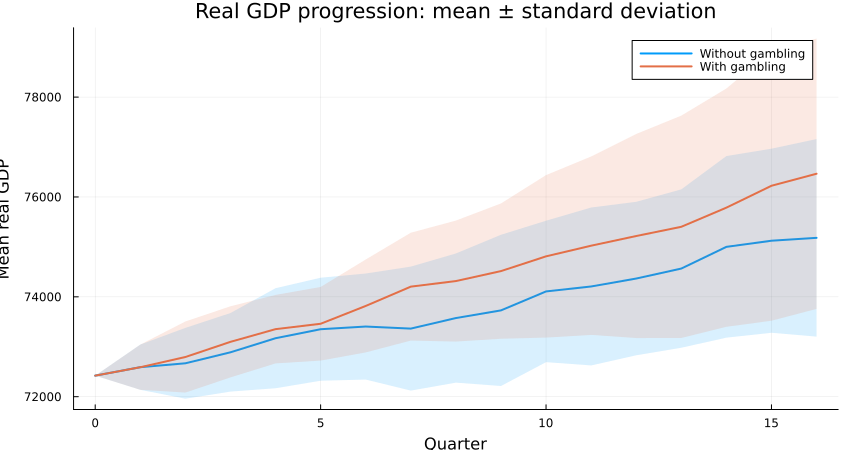

In [14]:
gdp_path = first(path for path in (
    joinpath(pwd(), "paired-gdp-paths.csv"),
    joinpath(pwd(), "dba-studies", "gambling-market", "paired-gdp-paths.csv"),
) if isfile(path))

gdp_paths = CSV.read(gdp_path, DataFrame)
@assert nrow(gdp_paths) == 20 * 2 * 17

gdp_progression = combine(
    groupby(gdp_paths, [:scenario, :period]),
    :real_gdp => mean => :mean_real_gdp,
    :real_gdp => std => :std_real_gdp,
)
sort!(gdp_progression, [:scenario, :period])

baseline_gdp = filter(:scenario => ==("baseline"), gdp_progression)
gambling_gdp = filter(:scenario => ==("gambling"), gdp_progression)

plot(
    baseline_gdp.period,
    baseline_gdp.mean_real_gdp;
    ribbon = baseline_gdp.std_real_gdp,
    fillalpha = 0.15,
    label = "Without gambling",
    xlabel = "Quarter",
    ylabel = "Mean real GDP",
    title = "Real GDP progression: mean ± standard deviation",
)

plot!(
    gambling_gdp.period,
    gambling_gdp.mean_real_gdp;
    ribbon = gambling_gdp.std_real_gdp,
    fillalpha = 0.15,
    label = "With gambling",
)

## Construct paired differences

For every outcome, the paired difference is `gambling − baseline`. A positive value means the outcome was higher with gambling.

In [4]:
outcomes = [
    :final_real_gdp,
    :final_active_worker_deposits,
    :final_inactive_worker_deposits,
    :final_owner_deposits,
    :cumulative_household_consumption,
    :cumulative_gambling_volume,
]

baseline = sort(filter(:scenario => ==("baseline"), results), :run)
gambling = sort(filter(:scenario => ==("gambling"), results), :run)

@assert baseline.run == gambling.run
@assert baseline.simulation_seed == gambling.simulation_seed

paired = select(baseline, :run, :simulation_seed)

for outcome in outcomes
    baseline_values = baseline[!, outcome]
    gambling_values = gambling[!, outcome]
    paired[!, Symbol(outcome, :_baseline)] = baseline_values
    paired[!, Symbol(outcome, :_gambling)] = gambling_values
    paired[!, Symbol(outcome, :_difference)] = gambling_values - baseline_values
end

paired

Row,run,simulation_seed,final_real_gdp_baseline,final_real_gdp_gambling,final_real_gdp_difference,final_active_worker_deposits_baseline,final_active_worker_deposits_gambling,final_active_worker_deposits_difference,final_inactive_worker_deposits_baseline,final_inactive_worker_deposits_gambling,final_inactive_worker_deposits_difference,final_owner_deposits_baseline,final_owner_deposits_gambling,final_owner_deposits_difference,cumulative_household_consumption_baseline,cumulative_household_consumption_gambling,cumulative_household_consumption_difference,cumulative_gambling_volume_baseline,cumulative_gambling_volume_gambling,cumulative_gambling_volume_difference
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,10001,74091.7,76059.8,1968.11,1.20369e5,1.21572e5,1203.27,64116.4,64768.8,652.371,41280.3,41826.8,546.468,6.65335e5,676357.0,11021.5,0.0,1124.74,1124.74
2,2,10002,73539.3,77074.0,3534.62,1.18066e5,119584.0,1518.49,62954.1,63727.0,772.871,40329.1,41221.6,892.481,6.92071e5,6.85238e5,-6833.15,0.0,1129.24,1129.24
3,3,10003,72975.9,74063.1,1087.27,118954.0,1.19885e5,930.587,63349.3,63905.8,556.567,40814.1,41112.8,298.727,6.7841e5,6.86761e5,8351.3,0.0,1150.98,1150.98
4,4,10004,70694.2,76680.2,5986.03,1.16877e5,1.20939e5,4062.57,62177.7,64451.1,2273.44,39850.1,41266.1,1415.95,646495.0,6.66739e5,20244.3,0.0,1081.26,1081.26
5,5,10005,74945.6,76701.3,1755.66,119309.0,1.22533e5,3223.76,63559.7,65298.9,1739.24,41083.3,42084.3,1000.93,6.68411e5,6.70799e5,2388.62,0.0,1120.55,1120.55
6,6,10006,76520.8,77418.5,897.701,1.18469e5,1.20293e5,1823.89,63162.1,64155.1,992.977,40677.8,41387.2,709.378,6.83069e5,676539.0,-6529.68,0.0,1108.25,1108.25
7,7,10007,75002.2,75522.2,519.968,1.19807e5,1.18883e5,-924.03,63875.3,63283.8,-591.456,40807.5,40999.4,191.878,6.71794e5,6.54272e5,-17521.2,0.0,1086.6,1086.6
8,8,10008,72505.2,74755.8,2250.55,1.18552e5,1.17639e5,-913.303,63218.1,62715.0,-503.123,39974.8,40155.7,180.85,6.74386e5,6.62781e5,-11604.9,0.0,1099.13,1099.13
9,9,10009,76951.4,77141.7,190.331,1.19426e5,1.20533e5,1106.89,63765.6,64345.6,580.037,40655.8,41155.9,500.165,6.99587e5,7.09507e5,9920.31,0.0,1203.14,1203.14


## Summary across the 20 pairs

The confidence interval is the usual 95% normal approximation for the mean paired difference. Percent changes are omitted for gambling volume because its baseline is zero.

In [5]:
summary = DataFrame(
    outcome = String[],
    baseline_mean = Float64[],
    gambling_mean = Float64[],
    mean_difference = Float64[],
    ci95_lower = Float64[],
    ci95_upper = Float64[],
    mean_percent_difference = Union{Missing, Float64}[],
    positive_runs = Int[],
)

for outcome in outcomes
    baseline_values = baseline[!, outcome]
    gambling_values = gambling[!, outcome]
    differences = gambling_values - baseline_values
    margin = 1.96 * std(differences) / sqrt(length(differences))
    percent_difference = all(iszero, baseline_values) ? missing :
        mean(100 .* differences ./ baseline_values)

    push!(summary, (
        string(outcome),
        mean(baseline_values),
        mean(gambling_values),
        mean(differences),
        mean(differences) - margin,
        mean(differences) + margin,
        percent_difference,
        count(>(0), differences),
    ))
end

summary

Row,outcome,baseline_mean,gambling_mean,mean_difference,ci95_lower,ci95_upper,mean_percent_difference,positive_runs
,String,Float64,Float64,Float64,Float64,Float64,Float64?,Int64
1,final_real_gdp,75181.5,76465.3,1283.77,56.2175,2511.33,1.7473,14
2,final_active_worker_deposits,1.19784e5,1.20144e5,360.003,-638.123,1358.13,0.312675,12
3,final_inactive_worker_deposits,63841.3,64037.7,196.432,-331.199,724.063,0.320381,12
4,final_owner_deposits,41028.7,41291.5,262.782,-164.042,689.606,0.652229,14
5,cumulative_household_consumption,6.77876e5,6.78558e5,682.53,-6040.12,7405.18,0.123965,9
6,cumulative_gambling_volume,0.0,1121.7,1121.7,1107.84,1135.55,missing,20


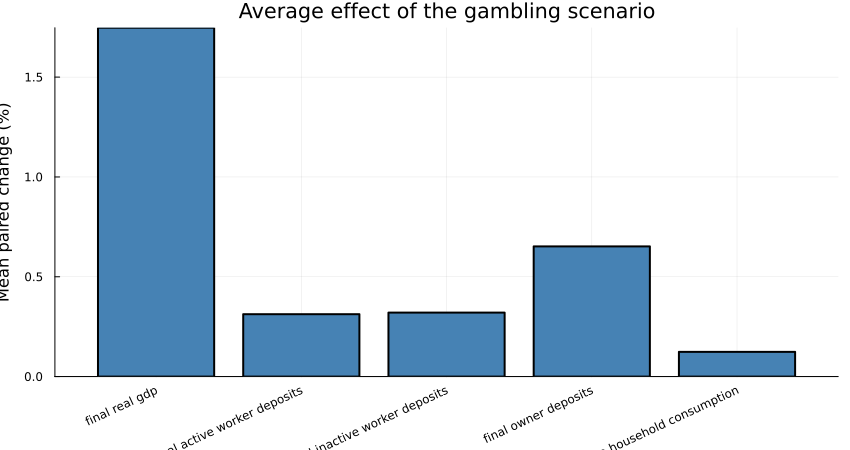

In [6]:
plot_outcomes = outcomes[1:end-1]
labels = replace.(string.(plot_outcomes), "_" => " ")
mean_percent_changes = coalesce.(summary.mean_percent_difference[1:end-1], 0.0)

bar(
    labels,
    mean_percent_changes;
    legend = false,
    ylabel = "Mean paired change (%)",
    title = "Average effect of the gambling scenario",
    xrotation = 25,
    color = ifelse.(mean_percent_changes .>= 0, :steelblue, :indianred),
)
hline!([0]; color = :black, linewidth = 1)

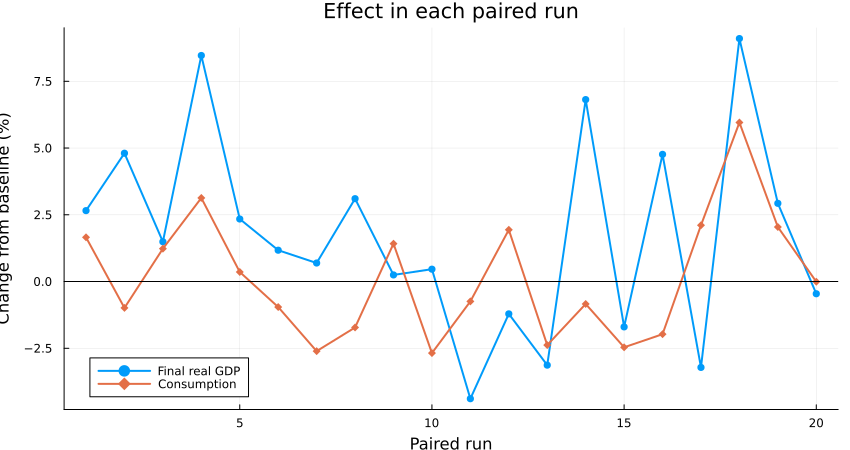

In [7]:
gdp_change = 100 .* paired.final_real_gdp_difference ./ paired.final_real_gdp_baseline
consumption_change = 100 .* paired.cumulative_household_consumption_difference ./
    paired.cumulative_household_consumption_baseline

plot(
    paired.run,
    gdp_change;
    marker = :circle,
    label = "Final real GDP",
    xlabel = "Paired run",
    ylabel = "Change from baseline (%)",
    title = "Effect in each paired run",
)
plot!(paired.run, consumption_change; marker = :diamond, label = "Consumption")
hline!([0]; color = :black, linewidth = 1, label = false)

In [8]:
describe(select(
    gambling,
    :active_gamblers,
    :inactive_gamblers,
    :recipient_owners,
    :cumulative_gambling_volume,
))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,active_gamblers,410.75,395,413.0,432,0,Int64
2,inactive_gamblers,414.25,393,412.0,430,0,Int64
3,recipient_owners,62.0,62,62.0,62,0,Int64
4,cumulative_gambling_volume,1121.7,1071.76,1122.64,1203.14,0,Float64


In [19]:
tested_outcomes = [
    :final_real_gdp,
    :final_active_worker_deposits,
    :final_inactive_worker_deposits,
    :final_owner_deposits,
    :cumulative_household_consumption,
]

baseline = sort(filter(:scenario => ==("baseline"), results), :run)
gambling = sort(filter(:scenario => ==("gambling"), results), :run)

@assert baseline.run == gambling.run
@assert baseline.simulation_seed == gambling.simulation_seed

alpha = 0.05
number_of_tests = length(tested_outcomes)

significance = DataFrame(
    outcome = String[],
    mean_difference = Float64[],
    standard_error = Float64[],
    t_statistic = Float64[],
    degrees_of_freedom = Int[],
    p_value = Float64[],
    bonferroni_p_value = Float64[],
    ci95_lower = Float64[],
    ci95_upper = Float64[],
    significant = Bool[],
)

for outcome in tested_outcomes
    differences = gambling[!, outcome] - baseline[!, outcome]

    n = length(differences)
    mean_difference = mean(differences)
    standard_error = std(differences) / sqrt(n)
    degrees_of_freedom = n - 1

    if iszero(standard_error)
        t_statistic = iszero(mean_difference) ? 0.0 : sign(mean_difference) * Inf
        p_value = iszero(mean_difference) ? 1.0 : 0.0
        margin = 0.0
    else
        distribution = TDist(degrees_of_freedom)
        t_statistic = mean_difference / standard_error
        p_value = 2 * ccdf(distribution, abs(t_statistic))
        critical_value = quantile(distribution, 1 - alpha / 2)
        margin = critical_value * standard_error
    end

    bonferroni_p_value = min(1.0, number_of_tests * p_value)

    push!(
        significance,
        (
            string(outcome),
            mean_difference,
            standard_error,
            t_statistic,
            degrees_of_freedom,
            p_value,
            bonferroni_p_value,
            mean_difference - margin,
            mean_difference + margin,
            bonferroni_p_value < alpha,
        ),
    )
end

significance

Row,outcome,mean_difference,standard_error,t_statistic,degrees_of_freedom,p_value,bonferroni_p_value,ci95_lower,ci95_upper,significant
,String,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Bool
1,final_real_gdp,1283.77,626.303,2.04976,19,0.0544479,0.272239,-27.0958,2594.64,false
2,final_active_worker_deposits,360.003,509.248,0.70693,19,0.48819,1.0,-705.866,1425.87,false
3,final_inactive_worker_deposits,196.432,269.199,0.72969,19,0.47448,1.0,-367.009,759.873,false
4,final_owner_deposits,262.782,217.767,1.20671,19,0.242353,1.0,-193.01,718.575,false
5,cumulative_household_consumption,682.53,3429.92,0.198993,19,0.844382,1.0,-6496.38,7861.44,false


## Reading the results

- `mean_difference` reports the average effect in model units.
- `mean_percent_difference` makes outcomes with different scales comparable.
- A 95% interval that crosses zero indicates that these 20 runs do not show a clear directional average effect under this approximation.
- `positive_runs` shows how consistently the effect points upward across the paired runs.